# Soldani - Second task - Benchmark

In [1]:
from pathlib import Path
import sys

# Find the root by searching the "src" folder
current = Path.cwd()

while current != current.parent:
    if (current / "src").exists():
        REPO_ROOT = current
        break
    current = current.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [ ]:
import json
import pandas as pd

from openai import OpenAI
from pgmpy.estimators import BayesianEstimator
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.effects import (
    total_variation, total_effect, spurious_effect,
    natural_direct_effect, natural_indirect_effect,
)

client = OpenAI()

/Users/marcosoldani/Desktop/SUPSI/tesi/fairmind-causal-fairness-analysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
CONFIG = {
    "dataset_name": "adult",
    "csv_path": "../../data/processed/adult.csv",
    "target_col":  "T_income",
    "target_val":  ">50K",
    "protected":   "S2_gender",
    "x0": "Female",
    "x1": "Male",
    "mediators":   ["hours-per-week"],
    "confounders": ["education"],
}

In [4]:
import time

def run_fairmind(config: dict) -> tuple[dict, float]:
    df = pd.read_csv(config["csv_path"])
    cols = (
        [config["protected"]]
        + config["mediators"]
        + config["confounders"]
        + [config["target_col"]]
    )
    df = df[cols].dropna()

    df = df.astype(str)

    sfm = build_sfm(
        sensitive_attr=config["protected"],
        outcome_attr=config["target_col"],
        confounder_attrs=config["confounders"],
        mediator_attrs=config["mediators"],
        sorted_mediators=len(config["mediators"]) > 1,
        sorted_confounders=len(config["confounders"]) > 1,
    )
    bn = fit_discrete_bayesian_model(
        sfm=sfm,
        data=df,
        estimator_instance=(BayesianEstimator, {"prior_type": "BDeu"}),
    )

    target = (config["target_col"], config["target_val"])
    x0, x1 = config["x0"], config["x1"]

    start = time.perf_counter()
    effects = {
        "TV": total_variation(bn, target, config["protected"], x0, x1),
        "TE": total_effect(bn, target, config["protected"], x0, x1),
        "SE": spurious_effect(bn, target, config["protected"], x0),
        "DE": natural_direct_effect(bn, target, config["protected"], x0, x1),
        "IE": natural_indirect_effect(bn, target, config["protected"], x1, x0),
    }
    elapsed = time.perf_counter() - start

    return effects, elapsed

ground_truth, fairmind_time = run_fairmind(CONFIG)
print(f"FairMind — elapsed time: {fairmind_time:.4f}s")
for k, v in ground_truth.items():
    print(f"  {k}: {v:.6f}")

2026-06-22 13:18:25.487 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'BDeu'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'hours-per-week': 'C', 'education': 'C', 'T_income': 'C'}
2026-06-22 13:18:25.534 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '>50K'), private_baseline=Female, private_mod=Male
2026-06-22 13:18:25.537 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '>50K'), private_value=Female


FairMind — elapsed time: 0.0073s
  TV: 0.194470
  TE: 0.183161
  SE: -0.007296
  DE: 0.137049
  IE: -0.046112


In [5]:
def build_gpt_prompt(config: dict, n_rows: int = 300) -> str:
    df = pd.read_csv(config["csv_path"])
    cols = (
        [config["protected"]]
        + config["mediators"]
        + config["confounders"]
        + [config["target_col"]]
    )
    df = df[cols].dropna()
    sample = df.sample(n=min(n_rows, len(df)), random_state=42)
    csv_str = sample.to_csv(index=False)

    return f"""You are a causal fairness expert. Compute five causal fairness effects
using the Standard Fairness Model (SFM) by Plecko and Bareinboim (2024).

DATASET ({len(sample)} rows):
{csv_str}

VARIABLE ROLES:
- X (protected): "{config['protected']}", x0="{config['x0']}", x1="{config['x1']}"
- Y (target):    "{config['target_col']}", target state="{config['target_val']}"
- W (mediators): {config['mediators']}
- Z (confounders): {config['confounders']}

IDENTIFICATION FORMULAE (use these exactly):
- TV = P(Y=y | X=x1) - P(Y=y | X=x0)
- TE = sum_z [P(Y=y|x1,z) - P(Y=y|x0,z)] * P(z)
- SE = TV - TE
- DE = sum_z,w [P(Y=y|x1,w,z) - P(Y=y|x0,w,z)] * P(w|x0,z) * P(z)
- IE = sum_z,w P(Y=y|x0,w,z) * [P(w|x1,z) - P(w|x0,z)] * P(z)

Return ONLY a JSON object, no other text:
{{
  "TV": <float>,
  "TE": <float>,
  "SE": <float>,
  "DE": <float>,
  "IE": <float>
}}"""

prompt = build_gpt_prompt(CONFIG)
print(prompt[:600], "\n[...]")

You are a causal fairness expert. Compute five causal fairness effects
using the Standard Fairness Model (SFM) by Plecko and Bareinboim (2024).

DATASET (300 rows):
S2_gender,hours-per-week,education,T_income
Female,40,HS-grad,<=50K
Male,40,HS-grad,<=50K
Female,40,Bachelors,>50K
Male,40,HS-grad,<=50K
Female,30,Bachelors,<=50K
Female,40,HS-grad,<=50K
Male,45,HS-grad,<=50K
Female,40,Bachelors,>50K
Male,50,HS-grad,<=50K
Female,40,Some-college,<=50K
Male,70,Some-college,<=50K
Male,30,Bachelors,<=50K
Male,40,Some-college,<=50K
Male,45,11th,<=50K
Male,40,Bachelors,<=50K
Male,60,Assoc-voc,<=50K
Femal 
[...]


In [ ]:
def call_gpt_effort(prompt: str, effort: str, model: str = "o3-mini") -> tuple[dict, dict, float]:
    start = time.perf_counter()
    response = client.responses.create(
        model=model,
        reasoning={"effort": "high"},
        input=[
            {
                "role": "user",
                "content": [{"type": "input_text", "text": prompt}],
            }
        ],
    )
    elapsed = time.perf_counter() - start

    usage = {
        "effort":           effort,
        "input_tokens":     response.usage.input_tokens,
        "output_tokens":    response.usage.output_tokens,
        "reasoning_tokens": response.usage.output_tokens_details.reasoning_tokens,
        "total_tokens":     response.usage.total_tokens,
    }

    # JSON Parsing
    raw = response.output_text.strip()
    
    # Remove backticks
    raw = response.output_text.strip().replace("```json", "").replace("```", "").strip()
    effects = json.loads(raw)

    return effects, usage, elapsed

EFFORTS = ["low", "medium", "high"]
gpt_runs = {}

for effort in EFFORTS:
    print(f"Call to GPT with effort='{effort}'...")
    gpt_effects, gpt_usage, gpt_time = call_gpt_effort(prompt, effort=effort)
    gpt_runs[effort] = {"effects": gpt_effects, "usage": gpt_usage, "time": gpt_time}
    print(f"  time: {gpt_time}:.3fs | "
          f"input: {gpt_usage['input_tokens']} | "
          f"output: {gpt_usage['output_tokens']} | "
          f"reasoning: {gpt_usage['reasoning_tokens']} | "
          f"total: {gpt_usage['total_tokens']}")
    print(json.dumps(gpt_effects, indent=2))

Call to GPT with effort='low'...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  time: 192.31860191699525:.3fs | input: 3662 | output: 65091 | reasoning: 32512 | total: 68753
{
  "TV": 0.1825,
  "TE": 0.1857,
  "SE": -0.0031,
  "DE": 0.1857,
  "IE": 0.0
}
Call to GPT with effort='medium'...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  time: 175.23482275000424:.3fs | input: 3662 | output: 74187 | reasoning: 37056 | total: 77849
{
  "TV": 0.1825,
  "TE": 0.1673,
  "SE": 0.0153,
  "DE": 0.12,
  "IE": 0.0473
}
Call to GPT with effort='high'...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  time: 203.09524029199383:.3fs | input: 3662 | output: 81359 | reasoning: 40640 | total: 85021
{
  "TV": 0.1826,
  "TE": 0.2541,
  "SE": -0.0715,
  "DE": 0.15,
  "IE": 0.104
}


In [7]:
def compute_discrepancies(ground_truth: dict, gpt_effects: dict) -> pd.DataFrame:
    rows = []
    for effect in ["TV", "TE", "SE", "DE", "IE"]:
        gt  = ground_truth.get(effect, float("nan"))
        gpt = float(gpt_effects.get(effect, float("nan")))
        abs_err = abs(gt - gpt)
        rel_err = abs_err / abs(gt) if abs(gt) > 1e-9 else float("nan")
        rows.append({
            "effect":      effect,
            "fairmind":    round(gt,  6),
            "gpt":         round(gpt, 6),
            "abs_error":   round(abs_err, 6),
            "rel_error_%": round(rel_err * 100, 2) if not pd.isna(rel_err) else float("nan"),
        })
    return pd.DataFrame(rows)

discrepancies_by_effort = {}

for effort, run in gpt_runs.items():
    disc = compute_discrepancies(ground_truth, run["effects"])
    disc["effort"] = effort
    discrepancies_by_effort[effort] = disc
    print(f"\n--- effort={effort} ---")
    print(disc.to_string(index=False))


--- effort=low ---
effect  fairmind     gpt  abs_error  rel_error_% effort
    TV  0.194470  0.1825   0.011970         6.16    low
    TE  0.183161  0.1857   0.002539         1.39    low
    SE -0.007296 -0.0031   0.004196        57.51    low
    DE  0.137049  0.1857   0.048651        35.50    low
    IE -0.046112  0.0000   0.046112       100.00    low

--- effort=medium ---
effect  fairmind    gpt  abs_error  rel_error_% effort
    TV  0.194470 0.1825   0.011970         6.16 medium
    TE  0.183161 0.1673   0.015861         8.66 medium
    SE -0.007296 0.0153   0.022596       309.70 medium
    DE  0.137049 0.1200   0.017049        12.44 medium
    IE -0.046112 0.0473   0.093412       202.58 medium

--- effort=high ---
effect  fairmind     gpt  abs_error  rel_error_% effort
    TV  0.194470  0.1826   0.011870         6.10   high
    TE  0.183161  0.2541   0.070939        38.73   high
    SE -0.007296 -0.0715   0.064204       879.98   high
    DE  0.137049  0.1500   0.012951         9.

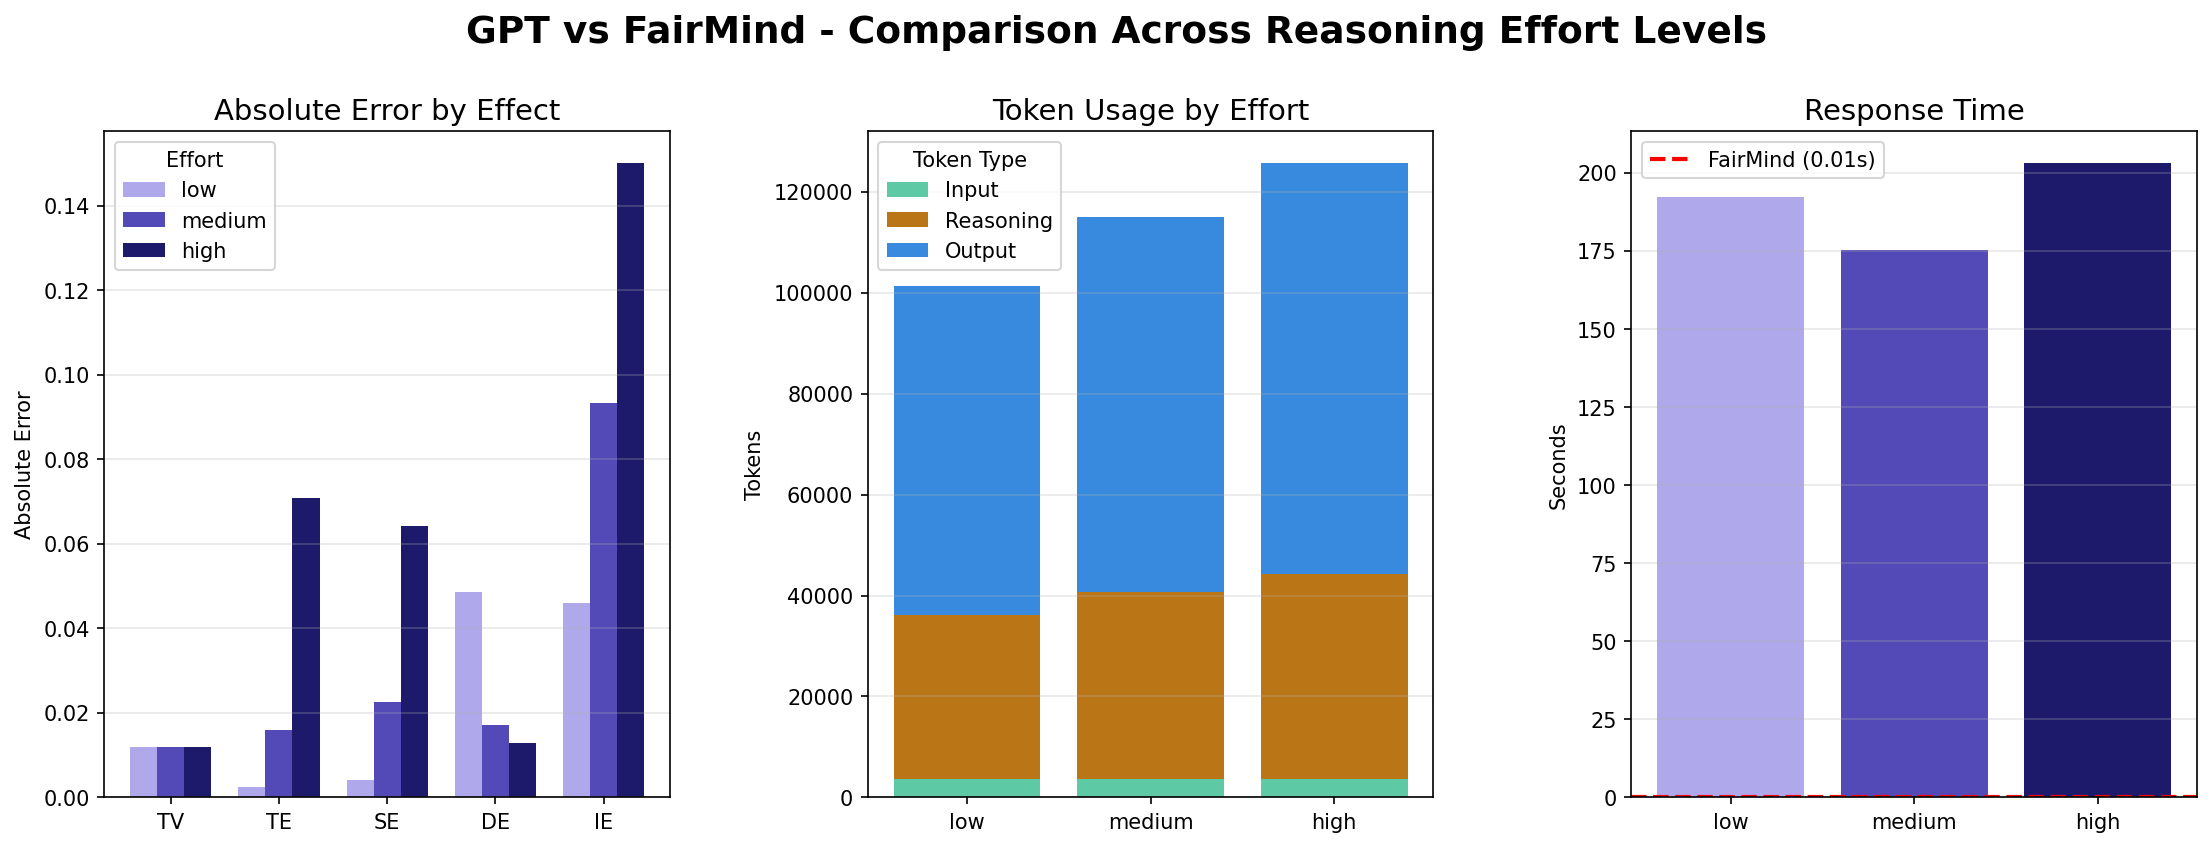

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import datetime

config = CONFIG["dataset_name"]
efforts = EFFORTS
effects = ["TV", "TE", "SE", "DE", "IE"]
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

colors = {
    "low": "#AFA9EC",
    "medium": "#534AB7",
    "high": "#1D1A6B"
}

x = np.arange(len(effects))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

fig.suptitle(
    "GPT vs FairMind - Comparison Across Reasoning Effort Levels",
    fontsize=18,
    fontweight="bold"
)

# ==========================
# Chart 1
# ==========================
ax = axes[0]

for i, effort in enumerate(efforts):
    vals = discrepancies_by_effort[effort]["abs_error"].tolist()

    ax.bar(
        x + (i - 1) * width,
        vals,
        width,
        label=effort,
        color=colors[effort]
    )

ax.set_title("Absolute Error by Effect", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(effects)
ax.set_ylabel("Absolute Error")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Effort")

# ==========================
# Chart 2
# ==========================
ax = axes[1]

token_types = [
    "input_tokens",
    "reasoning_tokens",
    "output_tokens"
]

token_labels = [
    "Input",
    "Reasoning",
    "Output"
]

token_colors = [
    "#5DCAA5",
    "#BA7517",
    "#378ADD"
]

bottoms = np.zeros(len(efforts))

for tok, lbl, col in zip(token_types, token_labels, token_colors):
    vals = [gpt_runs[e]["usage"][tok] for e in efforts]

    ax.bar(
        efforts,
        vals,
        bottom=bottoms,
        label=lbl,
        color=col
    )

    bottoms += np.array(vals)

ax.set_title("Token Usage by Effort", fontsize=14)
ax.set_ylabel("Tokens")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Token Type")

# ==========================
# Chart 3
# ==========================
ax = axes[2]

times = [gpt_runs[e]["time"] for e in efforts]

ax.bar(
    efforts,
    times,
    color=[colors[e] for e in efforts]
)

ax.axhline(
    fairmind_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"FairMind ({fairmind_time:.2f}s)"
)

ax.set_title("Response Time", fontsize=14)
ax.set_ylabel("Seconds")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.subplots_adjust(
    top=0.85,
    wspace=0.35
)

plt.savefig(
    f"benchmark_results/{config}_{effort}_{ts}_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
def save_results(config, ground_truth, gpt_effects, discrepancies, usage, fairmind_time, gpt_time, effort):
    import os, datetime
    os.makedirs("benchmark_results", exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    fname = f"benchmark_results/{config['dataset_name']}_{effort}_{ts}.json"

    out = {
        "dataset":       config["dataset_name"],
        "effort":        effort,
        "config":        {k: v for k, v in config.items() if k != "csv_path"},
        "fairmind":      ground_truth,
        "gpt":           gpt_effects,
        "discrepancies": discrepancies.to_dict(orient="records"),
        "token_usage":   usage,
        "timing": {
            "fairmind_seconds": round(fairmind_time, 5),
            "gpt_seconds":      round(gpt_time, 5),
        },
    }
    with open(fname, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Saved: {fname}")

for effort, run in gpt_runs.items():
    save_results(
        config=CONFIG, 
        ground_truth=ground_truth, 
        gpt_effects=run["effects"],
        discrepancies=discrepancies_by_effort[effort],
        usage=run["usage"],
        fairmind_time=fairmind_time,
        gpt_time=run["time"],
        effort=effort,
    )

Saved: benchmark_results/adult_low_20260622_132757.json
Saved: benchmark_results/adult_medium_20260622_132757.json
Saved: benchmark_results/adult_high_20260622_132757.json
